0.017520028498984173


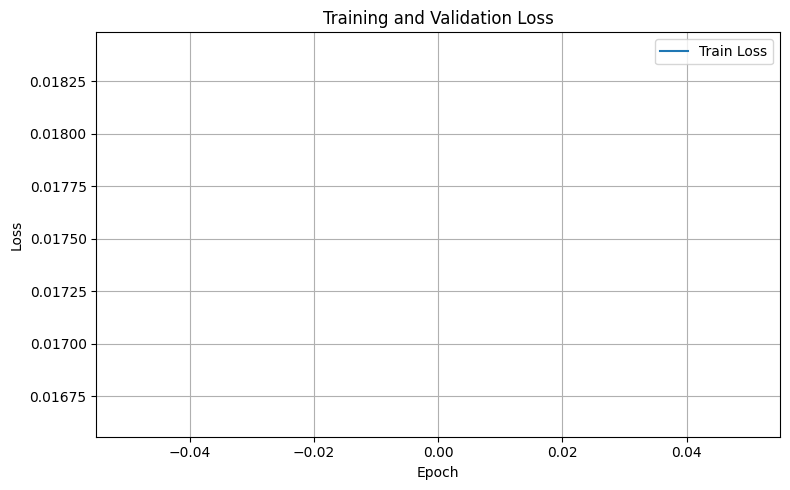

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the .npy files
train_loss = np.load('PATH TO TRAIN LOSS CHECKPOINT (.npy format)')
val_loss = np.load('PATH TO VAL LOSS CHECKPOINT (.npy format)')

print(train_loss)
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Train Loss')
#plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the .npy files
train_losses = []
train_loss_dir = np.load('PATH TO TRAIN LOSS CHECKPOINTS DIR')
for file in train_loss_dir:
    train_losses.append(np.load('train_losses_f'{file}.npy'))
    val_losses.append(np.load(file/'val_losses_f'{file}.npy'))

print(train_losses)
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Train Loss')
#plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (2599480900.py, line 8)

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path('PATH TO CHECKPOINT DIR')

train_losses = []
val_losses = []

# 1) find and sort epoch folders by number
epoch_dirs = sorted(
    [d for d in base_dir.iterdir() if d.is_dir()],
    key=lambda d: int(d.name.split('_')[1])
)

for epoch_dir in epoch_dirs:
    # 2) locate train/val files by substring match
    train_file = next(epoch_dir.glob('*train*loss*.npy'), None)
    val_file   = next(epoch_dir.glob('*val*loss*.npy'), None)

    if train_file and val_file:
        train_losses.append(np.load(train_file))
        val_losses = np.load(val_file)
        #print(np.load(val_file))
    else:
        print(f"⚠️  Missing file in {epoch_dir.name}:",
              f"train={train_file}, val={val_file}")

print(f"✅ Loaded {len(train_losses)} train and {len(val_losses)} val losses.")
print(train_losses)
print(val_losses)

✅ Loaded 9 train and 144 val losses.
[array(0.31287013), array(0.18155048), array(0.10356033), array(0.07822957), array(0.04902417), array(0.0307591), array(0.02440133), array(0.02219274), array(0.01752003)]
[0.77235978 0.65686455 0.59989055 0.55212421 0.51142156 0.46661723
 0.43128318 0.40545555 0.38989652 0.37448324 0.35861031 0.34891353
 0.34387732 0.33462891 0.32523287 0.32599292 0.44101317 0.38705747
 0.37156375 0.34075493 0.31843142 0.29727574 0.29246736 0.3372579
 0.36730247 0.34980234 0.35250818 0.35119528 0.34991989 0.35514774
 0.34841578 0.33937136 0.18646704 0.18178519 0.18082622 0.17820976
 0.17633282 0.17600686 0.17515692 0.17703957 0.18097531 0.18219165
 0.18339355 0.18452533 0.18851345 0.19160539 0.1905412  0.1896798
 0.14948215 0.15052595 0.15683405 0.15867565 0.16092219 0.1626412
 0.16349825 0.16396242 0.16419393 0.16450898 0.16531065 0.16658854
 0.17053759 0.18017492 0.18049686 0.17950737 0.15116464 0.15187009
 0.15436172 0.15715448 0.15964208 0.16168198 0.16334373 0.

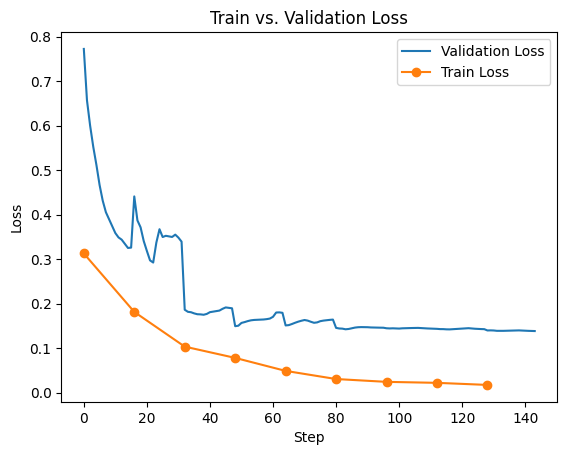

In [8]:
val_x = list(range(len(val_losses)))
block_size = len(val_losses) // len(train_losses)  # 40 // 5 = 8

# Place train losses at the start of each block
train_x = [i * block_size for i in range(len(train_losses))]

# Plotting
fig, ax = plt.subplots()

# validation loss curve
ax.plot(val_x, val_losses, label='Validation Loss')

# train loss markers + connecting line
ax.plot(train_x, train_losses, marker='o', linestyle='-', label='Train Loss')

# labels & legend
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Train vs. Validation Loss')
ax.legend()

plt.show()